# Test-Szenario A1
Wie gut können LLMs Feebdack zu den gegebenen Antworten geben?
_Könnte **Test-Szenarien S7, S8, S9** abdecken_

_Anwendbar auch für Test-Szenarien 3 und 4_
- _**Test-Szenario A3**: Evaluierung von verbesserten Spracheingaben -> wie oft wird das Gesprochene wie erwartet bewertet?_
- _**Test-Szenario A4**: Evaluierung von invarianten Spracheingaben -> wie oft, trotz Fehlern in der Eingabe, wird das Gesprochene wie erwartet bewertet? (deckt **Test-Szenario S3** ab)_
- _**Test-Szenario S2**: Erfolgt eine Ergänzungs-/Rückfrage wie erwartet?_

## Load Input Data

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

dir_path = Path(".")  # current directory
keep_cols = ["question_de", "answer_de", "max_points", "keywords", "transkript_stt_model", "human_score", "human_feedback",
             "rueckfrage", "error_type"]

dfs = []
for fp in sorted(dir_path.glob("*.tsv")):
    df_tmp = pd.read_csv(fp, sep="\t", dtype=str)
    df_tmp = df_tmp.reindex(columns=keep_cols)  # keeps order, fills missing with NA
    dfs.append(df_tmp)

df = pd.concat(dfs, ignore_index=True)  # appends; duplicates are kept
df["max_points"] = df["max_points"].str.replace(",", ".").astype(float)
df["human_score"] = df["human_score"].str.replace(",", ".").astype(float)
df["error_type"] = df["error_type"].astype(int)
df["rueckfrage"] = df["rueckfrage"].astype(int)

# check for column names: question_text, transkript_stt_model, gold_answer, maximal_score, human_score, human_feedback
df.head()

,question_de,answer_de,max_points,keywords,transkript_stt_model,human_score,human_feedback,rueckfrage,error_type
0,Was ist der Zweck von t-Tests in der EDA?,"T-Tests in der EDA werden verwendet, um die Mi...",6.0,t-Tests; unabhängige Stichproben; bekannter We...,EDA steht für explorative Datenanalyse. Tests ...,6.0,1) Die Antwort wurde fachlich korrekt dargeste...,0,1
1,Was ist der Zweck nicht-parametrischer Tests i...,Nicht-parametrische Tests in der EDA werden ve...,4.0,nicht-parametrische Tests; EDA; Annahmen param...,Nicht parametrische Tests in der idea werden v...,4.0,1) Die Antwort wurde fachlich korrekt dargeste...,0,1
2,Was ist der Zweck der explorativen Faktorenana...,Die explorative Faktorenanalyse (EFA) im Rahme...,4.0,explorative Faktorenanalyse; EDA; zugrunde lie...,"Der Zweck besteht darin, die Ursache oder aber...",4.0,1) Die Antwort wurde fachlich korrekt dargeste...,0,1
3,Was ist der Unterschied zwischen EFA und Haupt...,EFA und PCA sind beide Verfahren zur Reduktion...,6.0,EFA; PCA; Dimensionality Reduction; explorativ...,"Da ich nicht weiß wofür Fa steht, kann ich lei...",0.0,1) Die gegebene Antwort lässt keinen Rückschlu...,3,2
4,Was ist der Zweck eines Dendrogramms in der hi...,Ein Dendrogramm in der hierarchischen Clustera...,6.0,Dendrogramm; hierarchische Beziehungen; Mergin...,Ein Dendrogramm hilft in der hierarchischen Cl...,2.5,1) Die Antwort wurde fachlich korrekt dargeste...,2,2


In [2]:
len(df)

95

## Call LLMs

In [3]:
from llm_handler import LLMHandler
import json

# TODO: Write prompt for evaluation
prompt = """
Du bekommst eine Prüfungsfrage, die Antwort eines Studenten darauf, die Musterlösung zu der Frage und die maximal erreichbare Punktzahl für eine richtige Antwort.
Deine Aufgabe ist es, die Antwort des Studenten mit der Musterlösung zu vergleichen und diese zu bewerten.

Dabei sollst du dich an folgendem Leitfaden orientieren:
1) Hat der Student den Sachverhalt fachlich korrekt dargestellt, ohne wesentliche Fehler oder falsche Zusammenhänge?
2) Verwendet der Student die relevanten Schlüsselbegriffe korrekt und im richtigen Kontext? Schau dabei auf folgende Liste der wichtigsten Fachbegriffe: {keywords}.
3) Geht der Student auf alle wesentlichen Aspekte der Fragestellung ein oder bleiben zentrale Punkte unbeantwortet?
4) Werden die angesprochenen Konzepte klar voneinander unterschieden und nicht miteinander vermischt?
5) Ist die Antwort logisch aufgebaut, nachvollziehbar formuliert und für den Prüfer gut verständlich?
6) Soll vom Prüfer eine Rückfrage gestellt werden, um auf Lücken zu prüfen?

Deine Ausgabe soll aus folgenden Elementen bestehen:
- **llm_feedback**: In diesem Feld schreibst du die Bewertung zur Antwort des Studenten. Dabei gehst du auf jeden der oben genannten Punkte ein und formulierst anschließend einen Fließtext daraus. Beschränke dich bei dem Fließtext auf maximal 4-5 Sätze.
- **llm_rating**: Hier vergibst du die Punktzahl, die deiner Meinung nach die Antwort des Studenten wiederspiegelt. Du kannst die Punkte in 0,5 Schritten vergeben. Die maximal vergebbare Punktzahl ist {max_score}.
- **rueckfrage**: Du füllst dieses Feld mit einem Integer aus. Dieser Integer kann 0, 1, 2 oder 3 sein. 0 bedeutet, dass keine Rückfrage notwendig ist. 1 bedeutet, dass eine Rückfrage notwendig ist, die sich auf nicht genannte Fach- bzw. Schlüsselbegriffe bezieht. 2 bedeutet, dass eine Rückfrage gestellt wird und sich auf eine fehlende Teilantwort bezieht. 3 bedeutet, dass sich die gestellte Rückfrage auf einem Teil der falschen Antwort bezieht.

Frage:
{question}

Studentenantwort:
{student_answer}

Musterlösung:
{correct_answer}

Für diese Frage gibt es maximal {max_score} Punkte.

<Antwortformat>
```json
{{
"llm_feedback": "<Hier antwortest du auf die Antwort des Studenten und gibts ihm Feedback entsprechend der Analysepunkte. Die Antwort ist ein Text, es gibt keine JSON-Struktur>",
"llm_rating": "<Gesamtrating, maximale Punkte: {max_score}, gerundet auf eine Nachkommastelle>",
"rueckfrage": "<0 | 1 | 2 | 3>"
}}```
"""

In [4]:
import time

def _results_current_model(llm: LLMHandler, prompt: str, df: pd.DataFrame) -> pd.DataFrame:
  llm_results = []
  for _, row in df.iterrows():
    prompt_filled = prompt.format(
      question=row['question_de'],
      student_answer=row['transkript_stt_model'],
      keywords=row["keywords"],
      correct_answer=row['answer_de'],
      max_score=row['max_points']
    )
    while True:
      try:
        print(f"Try processing row {_}")
        answer = llm.call_llm(prompt=prompt_filled)
        if not isinstance(answer, dict):
          raise ValueError("LLM response is not a dictionary")
        answer["question"] = row['question_de']
        answer["student_answer"] = row['transkript_stt_model']
        answer["correct_answer"] = row['answer_de']
        answer["keywords"] = row["keywords"]
        answer["max_score"] = row['max_points']
        answer["human_score"] = row['human_score']
        answer["human_feedback"] = row['human_feedback']
        answer["rueckfrage_human"] = row["rueckfrage"]
        llm_results.append(answer)     
        with open("checkpoint_transcript.json", "a", encoding="utf-8") as f:
          f.write(json.dumps(answer, ensure_ascii=False) + "\n") 
        break
      except Exception as e:
        print(f"Error processing row {_}: {e}. Retrying in 5 seconds...")
        time.sleep(5)
  return pd.DataFrame(llm_results)

In [5]:
# models = ["gemma3:27b", "gemma3:4b", "deepseek-r1:8b", "llama3.1:latest", "command-r7b:latest", "mixtral:latest",
        #  "mistral-small3.1:latest", "llama3.3:latest", "phi4:latest"]

# for testing purposes
models = ["llama3.1:latest", "command-r7b:latest", "mixtral:latest"]

dfs = []

for model in models:
  llm_handler = LLMHandler(model=model)

  df_model = _results_current_model(llm_handler, prompt, df)
  df_model["model"] = model
  dfs.append(df_model)
  
final_df = pd.concat(dfs, ignore_index=True)

Try processing row 0
Error processing row 0: Expecting value: line 1 column 1 (char 0). Retrying in 5 seconds...
Try processing row 0
Error processing row 0: Expecting value: line 1 column 1 (char 0). Retrying in 5 seconds...
Try processing row 0
Try processing row 1
Try processing row 2
Try processing row 3
Error processing row 3: Expecting value: line 1 column 1 (char 0). Retrying in 5 seconds...
Try processing row 3
Error processing row 3: Expecting value: line 1 column 1 (char 0). Retrying in 5 seconds...
Try processing row 3
Error processing row 3: Expecting value: line 1 column 1 (char 0). Retrying in 5 seconds...
Try processing row 3
Error processing row 3: Expecting value: line 1 column 1 (char 0). Retrying in 5 seconds...
Try processing row 3
Error processing row 3: Expecting value: line 1 column 1 (char 0). Retrying in 5 seconds...
Try processing row 3
Error processing row 3: Expecting value: line 1 column 1 (char 0). Retrying in 5 seconds...
Try processing row 3
Error proces

In [6]:
final_df.to_csv("llm_evaluation_results_stt_second_try.csv", index=False)

## Evaluate LLM Answers

### Semantic Similarity of LLM Feedback with Human Feedback

In [7]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd
import torch

device = torch.device("cpu")

final_df = pd.concat([pd.read_csv("llm_evaluation_results_stt.csv"),
                      pd.read_csv("llm_evaluation_results_stt_second_try.csv")], ignore_index=True)

semantic_judge = SentenceTransformer("sentence-transformers/all-mpnet-base-v2")

def _semantic_similarity(a: str, b: str) -> float:
  """Calculate the semantic similarity between two texts using cosine similarity of their embeddings.

  Args:
      a (str): The first text to compare.
      b (str): The second text to compare.

  Returns:
      float: A float value between -1 and 1 indicating the semantic similarity between the two texts.
  """
  emb_a = semantic_judge.encode(a, convert_to_tensor=True).detach().cpu()
  emb_b = semantic_judge.encode(b, convert_to_tensor=True).detach().cpu()

  sim = cosine_similarity(emb_a.reshape(1, -1).numpy(), emb_b.reshape(1, -1).numpy())[0][0]
  
  return float(sim)

/Users/aleks/Desktop/FernUni_Hagen/EchoLearnBrainstorming/.conda/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
final_df

,llm_feedback,llm_rating,rueckfrage,question,student_answer,correct_answer,keywords,max_score,human_score,human_feedback,rueckfrage_human,model
0,Die Antwort des Studenten ist im Wesentlichen ...,5.0,1,Was ist der Zweck von t-Tests in der EDA?,EDA steht für explorative Datenanalyse. Tests ...,"T-Tests in der EDA werden verwendet, um die Mi...",t-Tests; unabhängige Stichproben; bekannter We...,6.0,6.0,1) Die Antwort wurde fachlich korrekt dargeste...,0,gemma3:27b
1,Die Antwort des Studenten ist im Wesentlichen ...,3.5,1,Was ist der Zweck nicht-parametrischer Tests i...,Nicht parametrische Tests in der idea werden v...,Nicht-parametrische Tests in der EDA werden ve...,nicht-parametrische Tests; EDA; Annahmen param...,4.0,4.0,1) Die Antwort wurde fachlich korrekt dargeste...,0,gemma3:27b
2,Die Antwort des Studenten ist im Wesentlichen ...,3.5,1,Was ist der Zweck der explorativen Faktorenana...,"Der Zweck besteht darin, die Ursache oder aber...",Die explorative Faktorenanalyse (EFA) im Rahme...,explorative Faktorenanalyse; EDA; zugrunde lie...,4.0,4.0,1) Die Antwort wurde fachlich korrekt dargeste...,0,gemma3:27b
3,Die Antwort des Studenten ist leider nicht in ...,0.0,1,Was ist der Unterschied zwischen EFA und Haupt...,"Da ich nicht weiß wofür Fa steht, kann ich lei...",EFA und PCA sind beide Verfahren zur Reduktion...,EFA; PCA; Dimensionality Reduction; explorativ...,6.0,0.0,1) Die gegebene Antwort lässt keinen Rückschlu...,3,gemma3:27b
4,Die Antwort des Studenten ist im Wesentlichen ...,4.5,1,Was ist der Zweck eines Dendrogramms in der hi...,Ein Dendrogramm hilft in der hierarchischen Cl...,Ein Dendrogramm in der hierarchischen Clustera...,Dendrogramm; hierarchische Beziehungen; Mergin...,6.0,2.5,1) Die Antwort wurde fachlich korrekt dargeste...,2,gemma3:27b
...,...,...,...,...,...,...,...,...,...,...,...,...
946,Der Student hat in seiner Antwort nicht ganz d...,2.5,1,Was ist der Zweck von Histogrammen in der EDA?,"Histogramme werden in der Idea verwendet, um d...",Histogramme in der EDA zeigen die Häufigkeitsv...,Histogramme; EDA; Häufigkeitsverteilung; steti...,6.0,0.0,Die Antwort ist fachlich falsch: Histogramme d...,3,mixtral:latest
947,Die Antwort des Studenten enthält leider nur t...,2.5,1,Was ist der Zweck von Heatmaps in der EDA?,"Heatmaps werden in der Idea verwendet, um die ...",Heatmaps in der EDA visualisieren die Magnitud...,Heatmaps; EDA; Magnitude; Stärke einer Beziehu...,4.0,0.0,Die Antwort ist fachlich falsch: Heatmaps dien...,3,mixtral:latest
948,Die Antwort des Studenten zeigt gewisse Missve...,1.5,1,Was ist der Unterschied zwischen Korrelation u...,"Korrelation zeigt, welche Variable wichtiger i...",Korrelation misst die Stärke und Richtung der ...,Korrelation; Kausalität; lineare Beziehung; EDA,4.0,0.0,Die Antwort ist fachlich falsch: Korrelation z...,3,mixtral:latest
949,Der Student hat in seiner Antwort den Zweck st...,1.5,1,Was ist der Zweck statistischer Tests in der EDA?,Statistische Tests in der idea werden verwende...,Statistische Tests in der EDA werden verwendet...,Statistische Tests; EDA; Signifikanz; Populati...,4.0,0.0,Die Antwort ist fachlich falsch: Statistische ...,3,mixtral:latest


In [9]:
import re
import pandas as pd

from sacrebleu.metrics import CHRF

# --- BERTScore ---
from bert_score import score as bertscore_score

# --- Keyphrase extraction (LLM-frei) ---
import yake


# =============== chrF ===============
_chrf = CHRF(word_order=2)  # Standard: chrF++; gut für Deutsch/Paraphrasen

def chrf_score(pred: str, ref: str) -> float:
    pred = "" if pred is None else str(pred)
    ref  = "" if ref  is None else str(ref)
    # sacrebleu expects list of hypotheses and list-of-list references
    return float(_chrf.corpus_score([pred], [[ref]]).score / 100.0)  # 0..1


# =============== Sentence splitting (Deutsch) ===============
# Optional: spaCy, falls verfügbar (besser als Regex)
try:
    import spacy
    _nlp = spacy.load("de_core_news_sm")
    def split_sentences_de(text: str):
        text = "" if text is None else str(text).strip()
        if not text:
            return []
        doc = _nlp(text)
        return [s.text.strip() for s in doc.sents if s.text.strip()]
except Exception:
    _nlp = None
    def split_sentences_de(text: str):
        text = "" if text is None else str(text).strip()
        if not text:
            return []
        # einfache Heuristik: split nach . ! ? oder Zeilenumbrüchen
        parts = re.split(r"(?<=[\.\!\?])\s+|\n+", text)
        return [p.strip() for p in parts if p.strip()]


# =============== Error-Content-F1 ===============
# 1) "kritische" Sätze filtern (Fehler/Fehlendes/Unklarheit)
ERROR_CUES = [
    "falsch", "fehler", "fehlt", "fehlend", "unklar", "verwechselt", "widerspricht",
    "stimmt nicht", "nicht korrekt", "nicht richtig", "irreführ", "unvollständig",
    "kein", "nicht", "ohne", "aber", "jedoch"
]

def select_error_sentences(text: str):
    sents = split_sentences_de(text)
    out = []
    for s in sents:
        low = s.lower()
        if any(cue in low for cue in ERROR_CUES):
            out.append(s)
    # Falls nichts gefunden wurde: nimm den ganzen Text (damit F1 nicht immer 0 wird)
    if not out and text:
        out = [text]
    return out

# 2) Keyphrases extrahieren (YAKE)
_yake = yake.KeywordExtractor(
    lan="de", n=1, top=12,  # n=1 = unigrams; robust. Wenn du willst: n=2 für bigrams.
    dedupLim=0.9
)

STOPWORDS_DE = set("""
der die das ein eine einer eines einem einen und oder aber sowie als wie dass da
ist sind war waren wird werden wurde wurden im in am an auf aus bei für von zu
mit ohne nicht kein keine keinen keiner eines einem einen sehr mehr weniger
""".split())

def normalize_phrase(p: str) -> str:
    p = p.lower().strip()
    p = re.sub(r"[^\wäöüß\- ]+", " ", p)
    p = re.sub(r"\s+", " ", p).strip()
    return p

def extract_keyphrases(text: str):
    text = "" if text is None else str(text).strip()
    if not text:
        return set()
    kws = _yake.extract_keywords(text)
    phrases = set()
    for phrase, score in kws:
        ph = normalize_phrase(phrase)
        if not ph:
            continue
        # very short / stopword-only raus
        if ph in STOPWORDS_DE:
            continue
        if len(ph) < 3:
            continue
        phrases.add(ph)
    return phrases

def f1_sets(pred_set, ref_set) -> float:
    if not pred_set and not ref_set:
        return 1.0
    if not pred_set or not ref_set:
        return 0.0
    inter = len(pred_set & ref_set)
    prec = inter / len(pred_set) if pred_set else 0.0
    rec  = inter / len(ref_set) if ref_set else 0.0
    if prec + rec == 0:
        return 0.0
    return 2 * prec * rec / (prec + rec)

def error_content_f1(pred_feedback: str, ref_feedback: str) -> float:
    # filter auf kritische Sätze
    pred_err = " ".join(select_error_sentences(pred_feedback))
    ref_err  = " ".join(select_error_sentences(ref_feedback))

    pred_phrases = extract_keyphrases(pred_err)
    ref_phrases  = extract_keyphrases(ref_err)

    return float(f1_sets(pred_phrases, ref_phrases))


# =============== BERTScore-F1 (multilingual) ===============
# Empfehlung: multilinguales Modell, weil Deutsch.
BERTSCORE_MODEL = "xlm-roberta-large"  # robust, aber etwas langsamer

def bertscore_f1(preds, refs, batch_size=16):
    """
    preds, refs: Listen gleich lang
    returns: np.array F1 scores (0..1)
    """
    P, R, F1 = bertscore_score(
        cands=preds,
        refs=refs,
        model_type=BERTSCORE_MODEL,
        lang="de",
        batch_size=batch_size,
        verbose=False,
        rescale_with_baseline=True,  # oft stabiler zwischen Textlängen
    )
    return F1.cpu().numpy()


# =============== Apply auf DataFrame ===============
def add_feedback_metrics(df: pd.DataFrame,
                         human_col="human_feedback",
                         llm_col="llm_feedback",
                         batch_size=16) -> pd.DataFrame:
    out = df.copy()

    # Strings sichern
    out[human_col] = out[human_col].fillna("").astype(str)
    out[llm_col]   = out[llm_col].fillna("").astype(str)

    # chrF (row-wise)
    out["chrf"] = [
        chrf_score(p, r) for p, r in zip(out[llm_col].tolist(), out[human_col].tolist())
    ]

    # Error-Content-F1 (row-wise)
    out["error_content_f1"] = [
        error_content_f1(p, r) for p, r in zip(out[llm_col].tolist(), out[human_col].tolist())
    ]

    # BERTScore-F1 (batch)
    preds = out[llm_col].tolist()
    refs  = out[human_col].tolist()
    out["bertscore_f1"] = bertscore_f1(preds, refs, batch_size=batch_size)

    return out

In [10]:
final_df = add_feedback_metrics(
    final_df,
    human_col="human_feedback",
    llm_col="llm_feedback",
    batch_size=16
)

In [11]:
final_df["semantic_similarity"] = final_df.apply(
  lambda row: _semantic_similarity(row["llm_feedback"], row["human_feedback"]), axis=1
)

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


### Rückfrage erkennen

In [12]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix
)

# ------------------------------------------------------------
# 1) Robuste Spalten-/Typaufbereitung
# ------------------------------------------------------------
# Modellspalte robust wählen (dein DF nutzt "model", später taucht "model_name" auf)
MODEL_COL = "model_name" if "model_name" in final_df.columns else "model"

# Rueckfrage-Spalten robust casten
# Erwartete Spalten: llm: "rueckfrage" und human: "rueckfrage_human"
for col in ["rueckfrage", "rueckfrage_human"]:
    if col not in final_df.columns:
        raise KeyError(f"Spalte '{col}' fehlt in final_df. Verfügbare Spalten: {list(final_df.columns)}")

final_df["rueckfrage"] = pd.to_numeric(final_df["rueckfrage"], errors="coerce").fillna(-1).astype(int)
final_df["rueckfrage_human"] = pd.to_numeric(final_df["rueckfrage_human"], errors="coerce").fillna(-1).astype(int)

# Optional: ungültige Werte rausfiltern (z.B. -1 aus JSON decode fails etc.)
valid_mask = final_df["rueckfrage"].between(0, 3) & final_df["rueckfrage_human"].between(0, 3)
df_r = final_df[valid_mask].copy()

# Labels
type_labels = {
    0: "0=keine Rückfrage",
    1: "1=fehlende Schlüsselbegriffe",
    2: "2=fehlende Teilantwort",
    3: "3=falscher Teil -> nachhaken",
}

# ------------------------------------------------------------
# 2) Binary: Rückfrage erwartet? (ja/nein)
# ------------------------------------------------------------
df_r["llm_rueckfrage_expected"] = (df_r["rueckfrage"] > 0).astype(int)
df_r["human_rueckfrage_expected"] = (df_r["rueckfrage_human"] > 0).astype(int)

# ------------------------------------------------------------
# 3) Gesamtmetriken (über alle Modelle)
# ------------------------------------------------------------
y_true_bin = df_r["human_rueckfrage_expected"].values
y_pred_bin = df_r["llm_rueckfrage_expected"].values

y_true_type = df_r["rueckfrage_human"].values
y_pred_type = df_r["rueckfrage"].values

print("=== Gesamt: Rückfrage erwartet? (binary) ===")
print("Accuracy:", accuracy_score(y_true_bin, y_pred_bin))
print("Precision:", precision_score(y_true_bin, y_pred_bin, zero_division=0))
print("Recall:", recall_score(y_true_bin, y_pred_bin, zero_division=0))
print("F1:", f1_score(y_true_bin, y_pred_bin, zero_division=0))
print("\nConfusion Matrix (rows=true, cols=pred) for binary [0=no, 1=yes]:")
print(confusion_matrix(y_true_bin, y_pred_bin))

print("\n=== Gesamt: Art der Rückfrage (0/1/2/3) ===")
print("Accuracy:", accuracy_score(y_true_type, y_pred_type))
print("Macro-F1:", f1_score(y_true_type, y_pred_type, average="macro", zero_division=0))
print("\nClassification report:")
print(classification_report(y_true_type, y_pred_type, digits=3, zero_division=0))
print("Confusion Matrix (rows=true, cols=pred) for types [0,1,2,3]:")
print(confusion_matrix(y_true_type, y_pred_type, labels=[0,1,2,3]))

# ------------------------------------------------------------
# 4) Pro-Modell Auswertung
# ------------------------------------------------------------
rows = []
for model_name, g in df_r.groupby(MODEL_COL):
    ytb = g["human_rueckfrage_expected"].values
    ypb = g["llm_rueckfrage_expected"].values

    ytt = g["rueckfrage_human"].values
    ypt = g["rueckfrage"].values

    rows.append({
        MODEL_COL: model_name,
        "n": len(g),

        # binary
        "bin_acc": accuracy_score(ytb, ypb),
        "bin_f1": f1_score(ytb, ypb, zero_division=0),

        # type
        "type_acc": accuracy_score(ytt, ypt),
        "type_macro_f1": f1_score(ytt, ypt, average="macro", zero_division=0),
    })

df_rueckfrage_metrics = pd.DataFrame(rows).sort_values(["type_macro_f1","type_acc","bin_f1"], ascending=False)
display(df_rueckfrage_metrics)

# ------------------------------------------------------------
# 5) Wo ist das LLM "richtig", dass eine Rückfrage erwartet wird?
#    + noch besser: wo trifft es auch die Art?
# ------------------------------------------------------------
df_r["correct_expected"] = (df_r["llm_rueckfrage_expected"] == df_r["human_rueckfrage_expected"])
df_r["correct_type_exact"] = (df_r["rueckfrage"] == df_r["rueckfrage_human"])

# Fälle: beide sagen "Rückfrage ja"
df_r_expected_yes = df_r[(df_r["human_rueckfrage_expected"] == 1) & (df_r["llm_rueckfrage_expected"] == 1)].copy()
print(f"\nFälle, in denen beide 'Rückfrage JA' sagen: {len(df_r_expected_yes)} / {len(df_r)}")

# Innerhalb dieser Fälle: Art korrekt?
df_r_expected_yes["type_correct_within_yes"] = (df_r_expected_yes["rueckfrage"] == df_r_expected_yes["rueckfrage_human"])
print("...davon Art korrekt:", df_r_expected_yes["type_correct_within_yes"].mean())

# Optional: Beispiele anzeigen
cols_show = [
    MODEL_COL, "question", "student_answer",
    "rueckfrage_human", "rueckfrage",
    "human_feedback", "llm_feedback"
]

print("\nBeispiele: Rückfrage erwartet korrekt (JA) & Art korrekt (Top 10)")
display(
    df_r_expected_yes[df_r_expected_yes["type_correct_within_yes"]]
    .head(10)[cols_show]
)

print("\nBeispiele: Rückfrage erwartet korrekt (JA) aber Art FALSCH (Top 10)")
display(
    df_r_expected_yes[~df_r_expected_yes["type_correct_within_yes"]]
    .head(10)[cols_show]
)

# ------------------------------------------------------------
# 6) (Optional) Human-/LLM-Typen als Textlabel-Spalten (für Analyse/Plots)
# ------------------------------------------------------------
df_r["rueckfrage_human_label"] = df_r["rueckfrage_human"].map(type_labels)
df_r["rueckfrage_llm_label"] = df_r["rueckfrage"].map(type_labels)


=== Gesamt: Rückfrage erwartet? (binary) ===
Accuracy: 0.7150368033648791
Precision: 0.7169811320754716
Recall: 0.897133220910624
F1: 0.797003745318352

Confusion Matrix (rows=true, cols=pred) for binary [0=no, 1=yes]:
[[148 210]
 [ 61 532]]

=== Gesamt: Art der Rückfrage (0/1/2/3) ===
Accuracy: 0.29652996845425866
Macro-F1: 0.28705982728045665

Classification report:
              precision    recall  f1-score   support

           0      0.708     0.413     0.522       358
           1      0.067     0.500     0.118        62
           2      0.229     0.259     0.243       185
           3      0.797     0.159     0.265       346

    accuracy                          0.297       951
   macro avg      0.450     0.333     0.287       951
weighted avg      0.605     0.297     0.348       951

Confusion Matrix (rows=true, cols=pred) for types [0,1,2,3]:
[[148 154  50   6]
 [ 11  31  19   1]
 [ 23 107  48   7]
 [ 27 171  93  55]]


,model,n,bin_acc,bin_f1,type_acc,type_macro_f1
8,phi4:latest,90,0.777778,0.846154,0.488889,0.438519
6,mistral-small3.1:latest,92,0.684783,0.800000,0.391304,0.354648
2,gemma3:27b,95,0.747368,0.826087,0.284211,0.275463
4,llama3.1:latest,125,0.696000,0.786517,0.304000,0.252553
0,command-r7b:latest,109,0.706422,0.728814,0.348624,0.216667
1,deepseek-r1:8b,94,0.691489,0.797203,0.223404,0.210976
7,mixtral:latest,156,0.705128,0.772277,0.269231,0.204777
5,llama3.3:latest,95,0.726316,0.816901,0.200000,0.183469
3,gemma3:4b,95,0.715789,0.805755,0.178947,0.146717



Fälle, in denen beide 'Rückfrage JA' sagen: 532 / 951
...davon Art korrekt: 0.2518796992481203

Beispiele: Rückfrage erwartet korrekt (JA) & Art korrekt (Top 10)


,model,question,student_answer,rueckfrage_human,rueckfrage,human_feedback,llm_feedback
11,gemma3:27b,Welche gängigen Metriken werden für die Modell...,"Hier können Genauigkeit, Präzision, Rico F 1 S...",1,1,1) Die Antwort wurde fachlich korrekt dargeste...,Die Antwort des Studenten nennt einige relevan...
30,gemma3:27b,Welche Rolle spielt die Regularisierung bei de...,Regularisierung fördert Modelle mit kleineren ...,2,2,Die Antwort ist in den genannten Teilen fachli...,Die Antwort des Studenten ist inhaltlich korre...
31,gemma3:27b,Erkläre das Bias-Variance-Trade-off.,Dieser Trade Off ist der Kompromiss zwischen d...,3,3,"1) Die Antwort wurde, bis auf eine Verwechslun...",Die Antwort des Studenten zeigt ein grundlegen...
40,gemma3:27b,Welche Rolle spielt die Regularisierung bei de...,Regularisierung fördert Modelle mit kleineren ...,2,2,1) Die Teilantwort wurde fachlich korrekt darg...,Die Antwort des Studenten ist grundsätzlich ri...
50,gemma3:27b,Was ist der Zweck von Sentiment-Analyse in der...,sentimentanalyse befasst sich hauptsächlich mi...,1,1,Die Antwort vermittelt zwar das grundlegende K...,Die Antwort des Studenten ist grundsätzlich ri...
52,gemma3:27b,Was ist der Unterschied zwischen k-facher Kreu...,der Unterschied zwischen Kafferer Kreuz Validi...,2,2,Die Antwort stellt die Grundidee beider Kreuzv...,Die Antwort des Studenten zeigt ein grundlegen...
53,gemma3:27b,Was ist der Zweck einer Konfusionsmatrix in Kl...,eine konfusionsmatrix wird in klassikationsauf...,1,1,Die Antwort geht grundsätzlich in die richtige...,Die Antwort des Studenten identifiziert korrek...
55,gemma3:27b,Was ist die Varianz eines statistischen Schätz...,die Varianz eines statistischen Schätzers besc...,2,2,Die Antwort stellt das Konzept der Varianz nur...,"Die Antwort des Studenten ist im Kern korrekt,..."
56,gemma3:27b,Was ist der Unterschied zwischen parametrische...,parametrische Tests sind eher für genaue Messw...,1,1,Die Antwort beschreibt den Unterschied zwische...,Die Antwort des Studenten zeigt ein grundlegen...
72,gemma3:27b,Welche Rolle spielt die Regularisierung bei de...,Regularisierung fördert Modelle mit kleineren ...,2,2,"Die Antwort trifft den Kern der Wirkung, lässt...",Die Antwort des Studenten ist grundsätzlich ko...



Beispiele: Rückfrage erwartet korrekt (JA) aber Art FALSCH (Top 10)


,model,question,student_answer,rueckfrage_human,rueckfrage,human_feedback,llm_feedback
3,gemma3:27b,Was ist der Unterschied zwischen EFA und Haupt...,"Da ich nicht weiß wofür Fa steht, kann ich lei...",3,1,1) Die gegebene Antwort lässt keinen Rückschlu...,Die Antwort des Studenten ist leider nicht in ...
4,gemma3:27b,Was ist der Zweck eines Dendrogramms in der hi...,Ein Dendrogramm hilft in der hierarchischen Cl...,2,1,1) Die Antwort wurde fachlich korrekt dargeste...,Die Antwort des Studenten ist im Wesentlichen ...
5,gemma3:27b,Was ist der Zweck von Dimensionsreduktionstech...,Dimensiones Adaptionstechniken werden in der e...,3,1,1) Die Antwort wurde fachlich korrekt dargeste...,Die Antwort des Studenten ist im Wesentlichen ...
7,gemma3:27b,Was ist der Zweck von t-SNE in der EDA?,"TSNE ist eine Technik, die zur Visualisierung ...",3,2,1) Die Antwort enthielt zu viele Verwechslunge...,Die Antwort des Studenten zeigt ein grundlegen...
8,gemma3:27b,Was ist der Unterschied zwischen linearem Disk...,"Das weiß ich sehr gut, denn bei dem Thema habe...",3,1,1) Es wurde keine Antwort auf die Frage gegebe...,Die Antwort des Studenten ist leider nicht gee...
12,gemma3:27b,Was ist der Zweck des Hyperparameter-Tunings b...,"Das Hyperparameter Tuning hilft dabei, die bes...",2,1,1) Die Antwort wurde fachlich korrekt dargeste...,Die Antwort des Studenten ist grundsätzlich ko...
13,gemma3:27b,Was ist der Zweck des Modell-Deployments im EDA?,Das Modell beinhaltet das Bereitstellen von pr...,3,2,1) Die Antwort wurde in Teilen fachlich korrek...,Die Antwort des Studenten ist im Kern korrekt ...
14,gemma3:27b,Welche Arten der Regularisierung werden häufig...,"Es werden häufig Regularisierungen verwendet, ...",2,1,1) Die Antwort wurde fachlich korrekt dargeste...,Die Antwort des Studenten beschreibt korrekt d...
15,gemma3:27b,Was ist der Bias-Variance-Kompromiss im maschi...,Die Reduzierung des Bieres erhöht typischerwei...,2,1,1) Die Antwort wurde fachlich korrekt dargeste...,"Die Antwort des Studenten ist zwar kurz, aber ..."
16,gemma3:27b,Was ist der Zweck von Kreuzvalidierung in der ...,"Kreuzvalidierung wird verwendet, um die Leistu...",3,2,1) Die Antwort enthielt neben korrekten auch f...,Die Antwort des Studenten enthält zwar einige ...


In [13]:
def normalize(frage: int) -> bool:
  if frage in [1, 2, 3]:
    return True
  return False

In [14]:
final_df["rueckfrage"] = final_df["rueckfrage"].apply(normalize)
final_df["rueckfrage_human"] = final_df["rueckfrage_human"].apply(normalize)

In [15]:
# how can I compare how often LLM and human expected a follow-up question?
final_df.groupby("model")[["rueckfrage", "rueckfrage_human"]].sum()

,rueckfrage,rueckfrage_human
model,,
command-r7b:latest,53,65
deepseek-r1:8b,84,59
gemma3:27b,79,59
gemma3:4b,80,59
llama3.1:latest,98,80
llama3.3:latest,83,59
mistral-small3.1:latest,87,58
mixtral:latest,105,97
phi4:latest,73,57


### MAE for LLM Scores and Human Scores

In [17]:
import numpy as np

final_df["llm_rating"] = final_df["llm_rating"].str.replace(",", ".")
final_df["llm_rating"] = final_df["llm_rating"].str.replace("2.5/4.0", "2.5").astype(float)
final_df["abs_error"] = np.abs(final_df["human_score"] - final_df["llm_rating"].astype(float))
final_df["error_perf"] = 1 - (final_df["abs_error"] / final_df["max_score"])

In [22]:
final_df["grade_ok_05"] = (final_df["abs_error"] <= 0.5)
final_df["grade_ok_10"] = (final_df["abs_error"] <= 1.0)

grade_quality = final_df.groupby("model").agg(
    sem_sim_mean=("semantic_similarity", "mean"),
    exact_rate=("abs_error", lambda x: (x == 0).mean()),
    ok_05_rate=("grade_ok_05", "mean"),
    ok_10_rate=("grade_ok_10", "mean"),
)

## Comparison and metrics

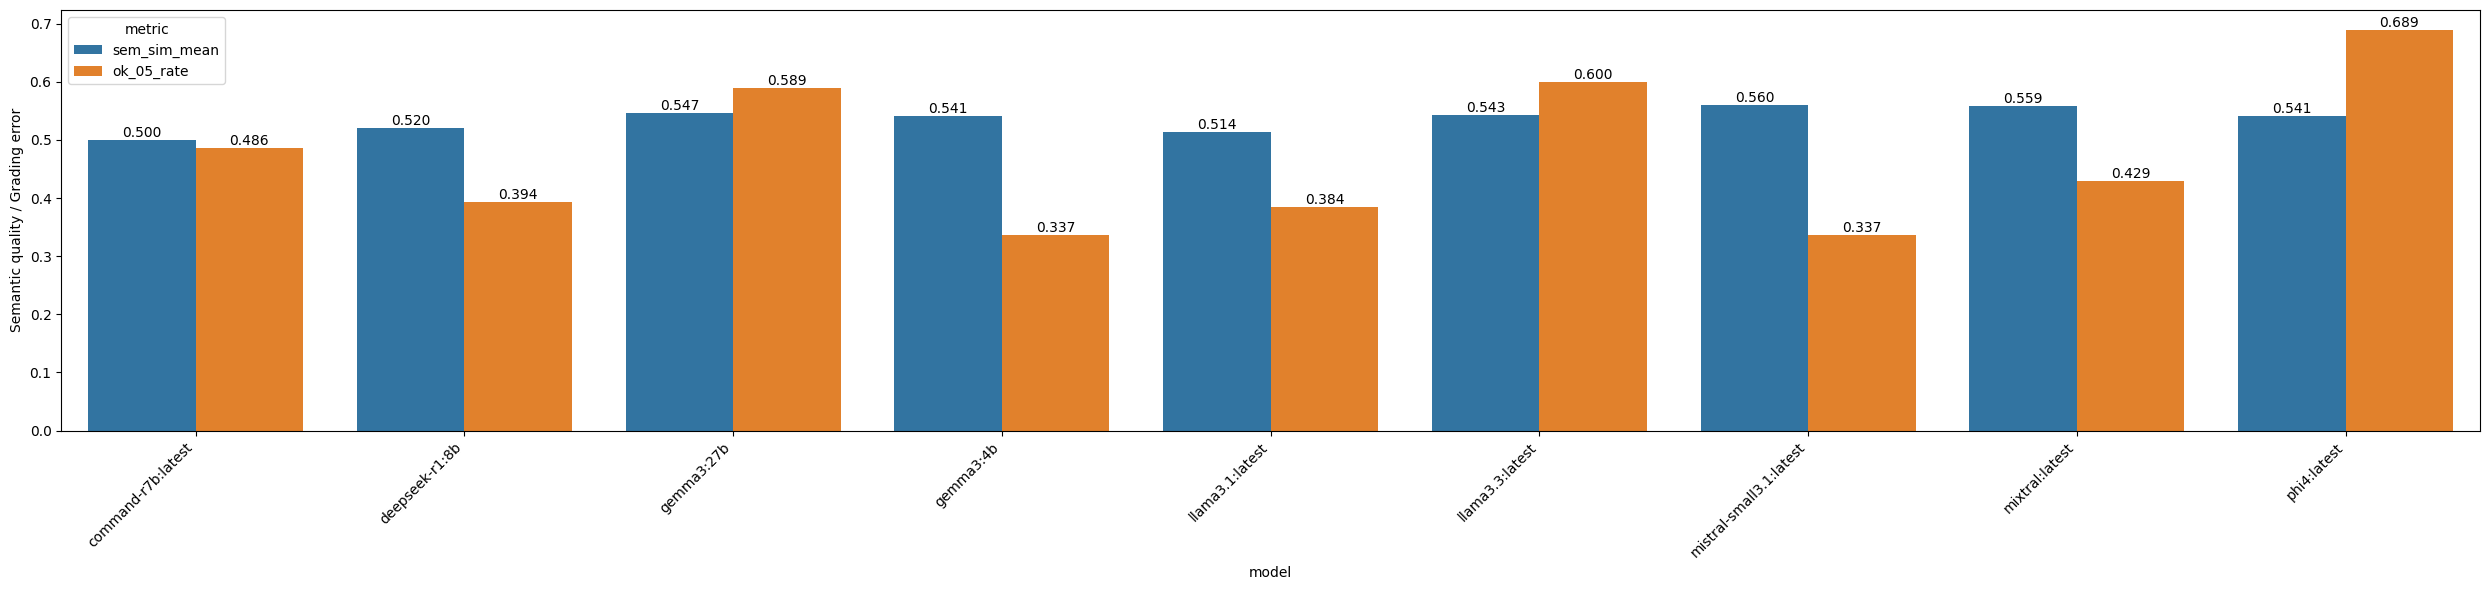

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

final_df["error_perf_neg"] = -final_df["error_perf"]

df_plot = grade_quality.reset_index().melt(
    id_vars="model",
    value_vars=["sem_sim_mean", "ok_05_rate"],
    var_name="metric",
    value_name="value"
)
plt.figure(figsize=(25,6))

ax = sns.barplot(data=df_plot, x="model", y="value", hue="metric")
ax.set_ylabel("Semantic quality / Grading error")

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()   
plt.show()

In [ ]:
agg = final_df.groupby("model")[[
    "chrf", "error_content_f1", "bertscore_f1",
    # falls du die auch schon hast:
    "abs_error", "error_perf"
]].mean().sort_values("bertscore_f1", ascending=False)

agg